# Machine Learning 2 - HW 2

## Submission Instructions

This notebook contains all the questions. You should follow the instructions below.
Solutions for both theoretical and practical parts should be written in this notebook.

You should submit three files:
- IPYNB notebook:
  - All the wet and dry parts, including code, graphs, discussion, etc.
- Model weights:
  - Export the model's weights after training using a `.pt` or `.pkl` file (question 2).
- PDF file:
  - Export the notebook to PDF. Make sure that all the cells are visible.

All files should be in the following format: "HW2_ID1_ID2.file"

Good Luck!

# Question 1 - Generalization and Overfit (20 pt)

In this exercise, we will demonstrate overfitting to random labels. The settings are the following:

<li> Use the MNIST dataset.
<li> For model training - work on the first 128 samples from the train split.
<li> Fix the following parameters:
    <ul>
        <li> Shuffle to False.
        <li> Batch size to 128.
        <li> Use seed = 42 for reproducibility.
    </ul>

Generate random labels from Bernoulli distribution with a probability of $\frac{1}{2}$ (I.e., each sample is assigned a random label which is zero or one).

Show that by using a simple Fully Connected netwrok and cross-entropy loss, you are able to achieve a loss value of $\approx 0$ (the lower the better).

Plot the accuracy and loss convergence for this data and the test split of our dataset as a function of epochs.

Answer the following questions:

1. Describe the accuracy value of the test data as a function of epochs and explain the phenomenon.

2. Discuss the connection between model size (complexity) and the dataset size. How does it relate to generalization and overfitting?

3. Discuss general methods to avoid overfitting. Specially, discuss methods in three different levels: data, model, and training.

4. Find one academic paper that presents or analyzes a method for reducing overfitting in deep learning.

    The method may be: general or domain-specific, architecture-specific (e.g., CNNs, Transformers), or applied to a particular task (e.g., vision, NLP, biomedical data).

    Briefly summarize:

    - The overfitting problem addressed in the paper (if there is one)

    - The proposed method for reducing overfitting

    - The main findings or conclusions

    Include a link for the paper.

    For example, you might delve into the connection between model size (complexity) and the dataset size stated in https://arxiv.org/pdf/2001.08361
</p>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
transform = transforms.ToTensor()

# Load MNIST
mnist_train = datasets.MNIST(root="./", train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root="./", train=False, download=True, transform=transform)

# Select the first 128 samples for training
train_imgs = mnist_train.data[:128].float().view(128, -1)
test_imgs  = mnist_test.data.float().view(len(mnist_test), -1)

train_imgs = train_imgs / 255.0
test_imgs  = test_imgs / 255.0

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


In [3]:
# Generate random labels {0, 1} for training
train_labels = torch.bernoulli(0.5 * torch.ones(128)).long()

# Generate random labels for testing as well
test_labels = torch.bernoulli(0.5 * torch.ones(len(test_imgs))).long()

print("Train labels sample:", train_labels[:10])
print("Test labels sample:", test_labels[:10])

Train labels sample: tensor([0, 0, 1, 0, 1, 0, 1, 0, 0, 1])
Test labels sample: tensor([0, 1, 0, 0, 1, 0, 1, 1, 1, 1])


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),  # Input: 28x28 pixels
            nn.ReLU(),
            nn.Linear(256, 2)     # Output: 2 classes (binary classification)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
epochs = 1000

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(epochs):

    model.train()
    outputs = model(train_imgs)
    loss = criterion(outputs, train_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    _, preds = outputs.max(1)
    train_acc = (preds == train_labels).float().mean().item()


    model.eval()
    with torch.no_grad():
        test_outputs = model(test_imgs)
        test_loss = criterion(test_outputs, test_labels).item()

        _, test_preds = test_outputs.max(1)
        test_acc = (test_preds == test_labels).float().mean().item()

    train_losses.append(loss.item())
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train loss={loss.item():.4f}, Train acc={train_acc:.4f} | "
          f"Test acc={test_acc:.4f}")

Epoch 1/1000 | Train loss=0.6970, Train acc=0.4688 | Test acc=0.4991
Epoch 2/1000 | Train loss=0.6587, Train acc=0.5547 | Test acc=0.5065
Epoch 3/1000 | Train loss=0.6295, Train acc=0.6719 | Test acc=0.5119
Epoch 4/1000 | Train loss=0.6026, Train acc=0.7500 | Test acc=0.5177
Epoch 5/1000 | Train loss=0.5787, Train acc=0.8203 | Test acc=0.5181
Epoch 6/1000 | Train loss=0.5557, Train acc=0.8047 | Test acc=0.5176
Epoch 7/1000 | Train loss=0.5330, Train acc=0.8203 | Test acc=0.5171
Epoch 8/1000 | Train loss=0.5114, Train acc=0.8203 | Test acc=0.5177
Epoch 9/1000 | Train loss=0.4904, Train acc=0.8203 | Test acc=0.5169
Epoch 10/1000 | Train loss=0.4694, Train acc=0.8281 | Test acc=0.5163
Epoch 11/1000 | Train loss=0.4486, Train acc=0.8359 | Test acc=0.5167
Epoch 12/1000 | Train loss=0.4279, Train acc=0.8516 | Test acc=0.5169
Epoch 13/1000 | Train loss=0.4072, Train acc=0.8516 | Test acc=0.5178
Epoch 14/1000 | Train loss=0.3871, Train acc=0.8750 | Test acc=0.5161
Epoch 15/1000 | Train loss=0.

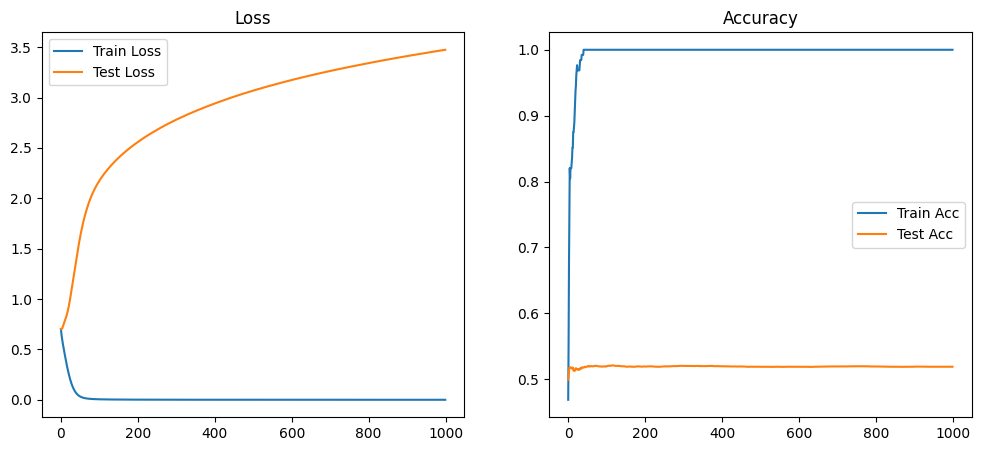

In [6]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [7]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

Total trainable parameters: 201474



## 1.

When training on random binary labels, the model rapidly memorizes the 128 training samples.  
This results in near-zero training loss and 100% training accuracy.

But the **test accuracy stays around 50%** for all epochs.  
This is exactly what we expect, because:

- The test labels are also random (Bernoulli(0.5)).
- The model cannot generalize beyond the small training set.
- The best possible performance on random labels is random guessing that's why ≈0.5 accuracy.

This behavior is the clearest example of **extreme overfitting**.


##  2.

Neural networks often have far more parameters than training samples.  
In this experiment:

- The fully-connected network has **201474 parameters**.
- The training set contains only **128 samples**.

A model that is too large compared to the dataset:

- Can perfectly memorize the training data and then achievestraining accuracy = 100%.
- Fails completely on the test set because memorization does not imply learning.

In general:

**Large model + small dataset = high risk of overfitting.**  
 **Generalization improves when model complexity matches dataset size.**


##  3.

###  Data Level
- **Data augmentation**  
  Increases the effective dataset size.
- **Collect more samples**  
  Reduces the model capacity gap.
- **Label smoothing / noise injection**  
  Prevents overconfident memorization.

###  Model Level
- **Reduce model size**  
  Smaller networks generalize better on small datasets.
- **Batch Normalization**  
  Stabilizes training and adds mild regularization.
- **Architectural choices** (for example pooling layers in CNNs)  
  Can reduce overfitting by enforcing structure.



### Training Level
- **Early stopping**  
  Stops training before memorization becomes extreme.
- **Learning rate scheduling**  
  Helps avoid overconfident fits.
- **Stochastic training (mini-batch optimization)**  
  Adds beneficial noise to gradients.

##  4.

**Paper:** Understanding Data Augmentation in Neural Machine Translation: Two Perspectives towards Generalization  
**Link:** https://aclanthology.org/D19-1570.pdf  

**Overfitting Problem Addressed**

The paper studies how data augmentation (DA) affects generalization in Neural Machine Translation (NMT is an approach to automatic translation that uses deep neural networks to encode a sentence in one language and generate its translation in another in an end-to-end manner.).  
Although DA is known to help reduce overfitting, prior results show inconsistent improvements across different datasets and translation tasks.  
This inconsistency makes it unclear what the true, stable benefits of DA are.

**Proposed Method for Reducing Overfitting**

The paper does not introduce a new augmentation technique.  
Instead, it analyzes five existing DA methods (RAML, SwitchOut, Self-Training, Target-Agreement, Back-Translation) and evaluates how they improve generalization.

The contribution is the introduction of two measures:

- **Input Sensitivity**  
    Measures how much the model’s loss changes when the input embeddings are slightly perturbed.  
   Lower sensitivity indicates that the model is more stable and less prone to overfitting.

- **Prediction Margin**  
   Defined as the difference between the probability assigned to the correct output token and the highest probability among incorrect tokens.  
    Larger margins correlate with better generalization.

These measures are computed directly on training samples, without relying on test sets.


**Main Findings / Conclusions**

- Data augmentation consistently reduces input sensitivity or increases prediction margin.
- The improvements are particularly notable for low-frequency words, where overfitting tends to be strongest.
- Overall, the paper concludes that DA systematically improves robustness and generalization in NMT models, regardless of variability in standard evaluation metrics.

********************

<h1> Question 2 - Sentiment Analysis - Classification (70 pt)</h1>

The goal of this exercise is to get familiar with recurrent neural networks.
<br><br>
Text emotion recognition, AKA sentiment analysis, is a rapidly growing field due to its practical applications. For instance, companies may be interested in classifying customer reviews as positive or negative to understand user satisfaction.
<br><br>
In this exercise, you will detect the emotion of a sentence. You will implement two models - RNN and LSTM. You need to reach at least 51% and 70% accuracy on the test set with RNN-based and LSTM-based models, respectively.
<br><br>
You should:
  <li> Use different optimization and regularization methods. </li>
  <li> Try different combinations of hyperparamters.</li>
</ul>
</p>

<br>

### Data

You will work with IMDB dataset, containing movie reviews and their labels according to the emotion conveyed in the review [positive, negative]. The dataset is divided into train and test sets (folders), each contains a folder for positive and negative reviews.
<br>

The dataset vocabulary is given (`imdb.vocab`). Feel free to use it or any other custom vocabulary.

### Tips


- Instead of using One-hot embeddings for the data, use <code>nn.Embedding</code>.

- Tokenization ("model language for text") - use word-based tokenization (each word is a token).

- You also might add "Start Of Sentence" (SOS) and "End Of Sentence" (EOS), "padding" (PAD) and "unknown" (UNK) tokens (self-learning). Note, to use them you have to insert them manually to your vocabulary and to the dataset's text.

    You are given `VocabEmbedding` for word-embedding management. The class loads the dataset's vocabulary and assigns an embedding for each word in it (+ special tokens). Feel free to use it as part of your model. Note, the embeddings are trainable and the class is a torch.nn class.

- Use GPU.

- It's recommended to use Deep RNN\LSTM (number of recurrent layers stacked on top of each other). For example, using `num_layers` in `nn.RNN`.

### a) EDA (10 pt)

Explore and analyze your data. Explain your data cleaning and processing pipeline.

In [8]:
# Upload the .tar.gz file from your local machine
from google.colab import files
uploaded = files.upload()

# Get the uploaded filename
tar_path = next(iter(uploaded))
print("Uploaded file:", tar_path)

# Extract the archive
import tarfile

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path="/content")

print("Extraction completed.")

# List extracted content
import os

print("\nContent of /content:")
os.listdir("/content")

Saving aclImdb_v1.tar.gz to aclImdb_v1.tar (1).gz
Uploaded file: aclImdb_v1.tar (1).gz


/tmp/ipython-input-3112088866.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


Extraction completed.

Content of /content:


['.config',
 'rnn_340868488_340872084.pkl',
 'aclImdb_v1.tar (1).gz',
 'MNIST',
 'aclImdb_v1.tar.gz',
 'lstm_340868488_340872084.pkl',
 'aclImdb',
 'sample_data']

In [9]:

import numpy as np

# Base dataset path
BASE_PATH = "/content/aclImdb"


# 1) Dataset structure

def count_txt_files(path):
    return len([f for f in os.listdir(path) if f.endswith(".txt")])

stats = {
    "train_pos": count_txt_files(f"{BASE_PATH}/train/pos"),
    "train_neg": count_txt_files(f"{BASE_PATH}/train/neg"),
    "test_pos": count_txt_files(f"{BASE_PATH}/test/pos"),
    "test_neg": count_txt_files(f"{BASE_PATH}/test/neg"),
}

print("Dataset statistics:")
for k, v in stats.items():
    print(f"{k}: {v}")


# 2) Qualitative inspection of raw text

sample_file = os.listdir(f"{BASE_PATH}/train/pos")[0]
with open(f"{BASE_PATH}/train/pos/{sample_file}", "r", encoding="utf-8") as f:
    sample_text = f.read()

print("Sample positive review (first 100 characters):")
print(sample_text[:100])


# 3) Review length analysis

def review_lengths(folder):
    lengths = []
    for fname in os.listdir(folder):
        if fname.endswith(".txt"):
            with open(os.path.join(folder, fname), "r", encoding="utf-8") as f:
                lengths.append(len(f.read().split()))
    return lengths

train_pos_lengths = review_lengths(f"{BASE_PATH}/train/pos")
train_neg_lengths = review_lengths(f"{BASE_PATH}/train/neg")

all_train_lengths = train_pos_lengths + train_neg_lengths

percentiles = np.percentile(all_train_lengths, [50, 75, 90, 95, 99])

print("\nReview length percentiles (number of words):")
for p, val in zip([50, 75, 90, 95, 99], percentiles):
    print(f"{p}th percentile: {int(val)} words")

print("\nSummary statistics:")
print(f"Min length: {min(all_train_lengths)}")
print(f"Max length: {max(all_train_lengths)}")
print(f"Mean length: {int(np.mean(all_train_lengths))}")


# 4) Vocabulary information

vocab_path = f"{BASE_PATH}/imdb.vocab"

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_size = len([line for line in f if line.strip()])

print(f"Vocabulary size (excluding special tokens): {vocab_size}")

Dataset statistics:
train_pos: 12500
train_neg: 12500
test_pos: 12500
test_neg: 12500
Sample positive review (first 100 characters):
This is a very fine and poetic story. Beautiful scenery. Magnificent music score. I've been twice in

Review length percentiles (number of words):
50th percentile: 174 words
75th percentile: 284 words
90th percentile: 458 words
95th percentile: 598 words
99th percentile: 913 words

Summary statistics:
Min length: 10
Max length: 2470
Mean length: 233
Vocabulary size (excluding special tokens): 89527


**Data Cleaning and Processing Pipeline**

The IMDB dataset consists of raw text files, where each file corresponds to a single review. Reviews are labeled implicitly according to their directory structure, with positive and negative samples stored in separate folders. Since the data is provided as free-form natural language text, a preprocessing pipeline is required to transform the reviews into a numerical format suitable for RNN.

Only minimal text cleaning is applied. All reviews are converted to lowercase in order to reduce vocabulary sparsity.

The text is tokenized at the word level. Each word is mapped to a numerical index using the provided vocabulary file (`imdb.vocab`). Words that do not appear in the vocabulary are replaced with a special unknown token. In addition, special tokens are manually added to mark the beginning and end of each review, as well as to handle padding.

Due to the variable length reviews, all sequences are either truncated or padded to a fixed maximum length. Truncation is applied to very long reviews to ensure stable training and reasonable memory usage, while shorter reviews are padded with a dedicated padding token. This results in fixed-length sequences that can be efficiently batched.

Finally, the sequences of word indices are passed through a trainable embedding layer, which maps each word to a dense vector representation. The resulting embedded sequences are used as input to the recurrent neural network models described in the next section.

*****************************

### b) Main (50 pt)

Define 2 models, as requested. Train and eval them.

- Plot the gated model's accuracy and loss (both on train and test sets) as a function of epochs.
- Plot a confusion matrix for the model outputs on the train and test sets.
- Did you observe differences in models training process?


Note, you are allowed to use `nn.RNN` and `nn.LSTM` in your model.


In [10]:
import torch.nn as nn
import torch

class VocabEmbedding(nn.Module):
    """
    Handles:
      - loading vocabulary from imdb.vocab
      - mapping word <-> index
      - embedding lookup
      - providing a method to get embedding for a single word
    """
    def __init__(self, vocab_path, embed_dim=128):
        super().__init__()

        # Load raw vocab file
        with open(vocab_path, "r", encoding="utf-8") as f:
            words = [line.strip() for line in f if line.strip()]

        # Add special tokens
        self.special_tokens = ["<pad>", "<unk>", "<sos>", "<eos>"]
        vocab = self.special_tokens + words
        word_to_token_index = {w: i for i, w in enumerate(vocab)}

        self.vocab = vocab
        self.word_to_token_index = word_to_token_index
        self.vocab_size = len(vocab)

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=self.vocab_size,
            embedding_dim=embed_dim,
            padding_idx=self.word_to_token_index["<pad>"],
        )

    def forward(self, x_ids):
        """
        x_ids: LongTensor of shape [B, T] with token indices
        returns: [B, T, E]
        """
        return self.embedding(x_ids)

    def word_to_id(self, word):
        return self.word_to_token_index.get(word, self.word_to_token_index["<unk>"])

    def id_to_word(self, idx):
        return self.vocab[idx]

    def get_word_embedding(self, word):
        """
        Returns the embedding vector for a single word (1D tensor of size [E]).
        """
        self.eval()
        idx = torch.tensor([self.word_to_id(word)], dtype=torch.long, device=self.embedding.weight.device)
        with torch.no_grad():
            emb = self.embedding(idx)  # [1, E]
        return emb.squeeze(0)         # [E]

In [11]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
class IMDBDataset(Dataset):
    def __init__(self, base_path, split, vocab, max_len=300):
        """
        split: 'train' or 'test'
        vocab: VocabEmbedding instance
        """
        self.samples = []
        self.vocab = vocab
        self.max_len = max_len
        self.pad_id = vocab.word_to_id("<pad>")

        for label, sentiment in enumerate(["neg", "pos"]):
            folder = os.path.join(base_path, split, sentiment)
            for fname in os.listdir(folder):
                if fname.endswith(".txt"):
                    self.samples.append((os.path.join(folder, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        with open(path, "r", encoding="utf-8") as f:
            text = f.read().lower()

        tokens = text.split()
        tokens = ["<sos>"] + tokens + ["<eos>"]

        ids = [self.vocab.word_to_id(tok) for tok in tokens]

        # Truncation
        ids = ids[:self.max_len]

        # Padding
        if len(ids) < self.max_len:
            ids += [self.pad_id] * (self.max_len - len(ids))

        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

In [21]:
BASE_PATH = "/content/aclImdb"
MAX_LEN = 200
BATCH_SIZE = 64

vocab = VocabEmbedding(f"{BASE_PATH}/imdb.vocab", embed_dim=128).to(device)

train_ds = IMDBDataset(BASE_PATH, "train", vocab, MAX_LEN)
test_ds  = IMDBDataset(BASE_PATH, "test", vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [19]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab, embed_dim=128, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = vocab
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, h_n = self.rnn(x)
        h_last = h_n[-1]
        return self.fc(h_last)

In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = vocab
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]
        return self.fc(h_last)

In [17]:
def run_epoch(model, loader, optimizer=None):
    """
    Runs one epoch on the given dataloader.
    If optimizer is provided -> training mode
    Else -> evaluation mode
    """
    if optimizer is not None:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if optimizer is not None:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [22]:
EPOCHS = 12

rnn = RNNClassifier(vocab).to(device)
opt_rnn = torch.optim.Adam(rnn.parameters(), lr=1e-3)

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(rnn, train_loader, opt_rnn)
    test_loss, test_acc = run_epoch(rnn, test_loader)

    print(
        f"[RNN] Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train acc = {train_acc*100:.1f}% | "
        f"Test acc = {test_acc*100:.1f}%"
    )

[RNN] Epoch 01/12 | Train acc = 50.0% | Test acc = 50.3%
[RNN] Epoch 02/12 | Train acc = 50.9% | Test acc = 50.5%
[RNN] Epoch 03/12 | Train acc = 50.9% | Test acc = 50.7%
[RNN] Epoch 04/12 | Train acc = 52.6% | Test acc = 51.2%
[RNN] Epoch 05/12 | Train acc = 54.3% | Test acc = 54.6%
[RNN] Epoch 06/12 | Train acc = 55.3% | Test acc = 51.6%
[RNN] Epoch 07/12 | Train acc = 58.3% | Test acc = 53.8%
[RNN] Epoch 08/12 | Train acc = 64.2% | Test acc = 58.8%
[RNN] Epoch 09/12 | Train acc = 64.7% | Test acc = 61.4%
[RNN] Epoch 10/12 | Train acc = 69.5% | Test acc = 58.4%
[RNN] Epoch 11/12 | Train acc = 69.6% | Test acc = 58.7%
[RNN] Epoch 12/12 | Train acc = 72.0% | Test acc = 59.8%


In [23]:
lstm = LSTMClassifier(vocab).to(device)
opt_lstm = torch.optim.Adam(lstm.parameters(), lr=1e-3)

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(lstm, train_loader, opt_lstm)
    te_loss, te_acc = run_epoch(lstm, test_loader)

    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["train_acc"].append(tr_acc)
    history["test_acc"].append(te_acc)

    print(
        f"[LSTM] Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train acc = {tr_acc*100:.1f}% | "
        f"Test acc = {te_acc*100:.1f}%"
    )

[LSTM] Epoch 01/12 | Train acc = 65.9% | Test acc = 58.8%
[LSTM] Epoch 02/12 | Train acc = 75.4% | Test acc = 70.4%
[LSTM] Epoch 03/12 | Train acc = 80.3% | Test acc = 65.8%
[LSTM] Epoch 04/12 | Train acc = 83.7% | Test acc = 72.5%
[LSTM] Epoch 05/12 | Train acc = 85.8% | Test acc = 73.0%
[LSTM] Epoch 06/12 | Train acc = 88.4% | Test acc = 75.8%
[LSTM] Epoch 07/12 | Train acc = 90.2% | Test acc = 75.7%
[LSTM] Epoch 08/12 | Train acc = 91.6% | Test acc = 74.7%
[LSTM] Epoch 09/12 | Train acc = 92.2% | Test acc = 75.5%
[LSTM] Epoch 10/12 | Train acc = 93.4% | Test acc = 76.1%
[LSTM] Epoch 11/12 | Train acc = 94.4% | Test acc = 77.6%
[LSTM] Epoch 12/12 | Train acc = 95.1% | Test acc = 77.4%


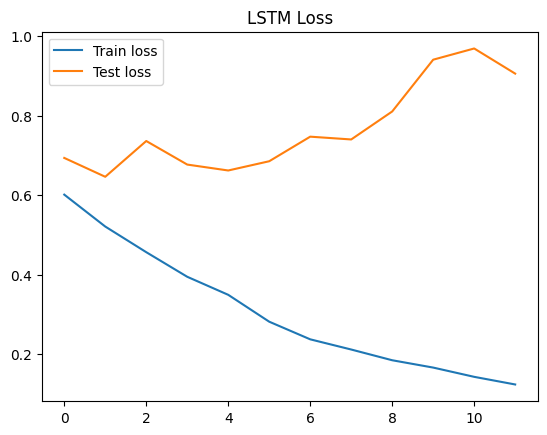

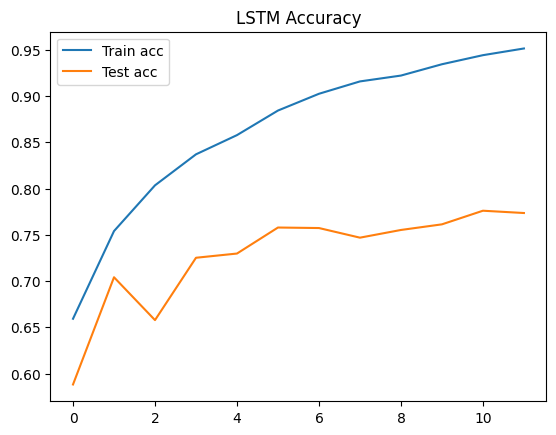

In [24]:
plt.figure()
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["test_loss"], label="Test loss")
plt.legend()
plt.title("LSTM Loss")
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="Train acc")
plt.plot(history["test_acc"], label="Test acc")
plt.legend()
plt.title("LSTM Accuracy")
plt.show()

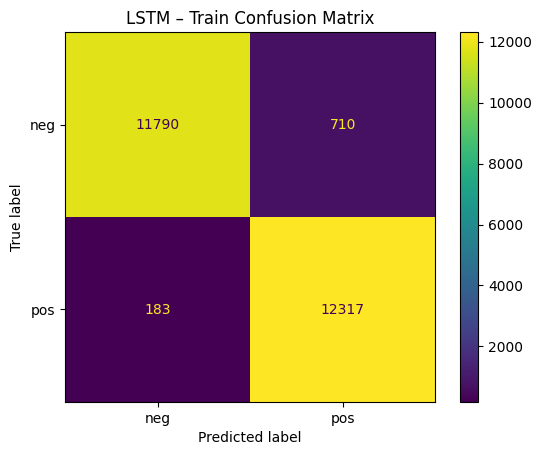

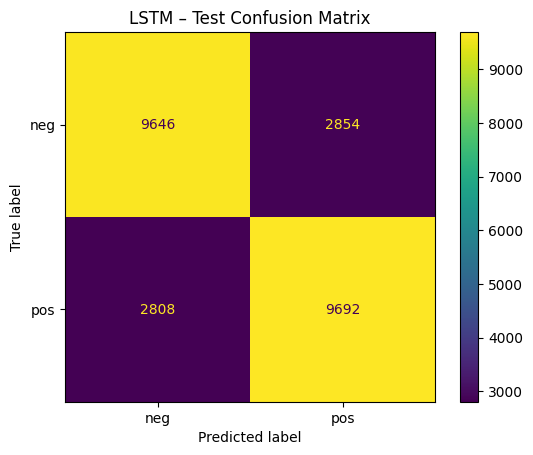

In [25]:
def plot_cm(model, loader, title):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["neg", "pos"])
    disp.plot()
    plt.title(title)
    plt.show()

plot_cm(lstm, train_loader, "LSTM – Train Confusion Matrix")
plot_cm(lstm, test_loader, "LSTM – Test Confusion Matrix")

In [26]:
torch.save(lstm.state_dict(), "lstm_340868488_340872084.pkl")
torch.save(rnn.state_dict(), "rnn_340868488_340872084.pkl")

**Differences in Training Process**

Clear differences were observed between the two models.

The RNN model learned slowly and showed unstable performance, with test accuracy fluctuating around the chance level (50%) before gradually improving. Even after tuning, its ability to generalize remained limited, indicating difficulty in capturing long-term dependencies in long text sequences.

In contrast, the LSTM model converged much faster and achieved significantly higher accuracy early in training. Its gating mechanisms allow it to retain and aggregate relevant information over long sequences, leading to more stable training and better generalization. A gap between training and test accuracy appeared after several epochs, suggesting overfitting.

*****************************

### c) Discussion (10 pt)

Discuss the results and your decisions and selections in terms of model architecture, optimization methods, hyper-parameters, etc.


**Data Processing and Input Representation**  
Reviews were tokenized at the word level and converted to sequences of word indices using a fixed vocabulary. Special tokens for the start and end of a sentence, unknown words, and padding were added manually. Due to the large variability in review lengths, sequences were truncated or padded to a maximum length of 200 tokens. This choice was made to reduce noise and mitigate vanishing gradient effects, especially for the RNN, while preserving enough contextual information for sentiment classification. A trainable embedding layer of dimension 128 was used in both models to learn task-specific word representations.

**Model Architectures**  
The RNN model consists of a two-layer RNN followed by a fully connected classification layer. The final hidden state of the last recurrent layer was used as a compact representation of the entire review. While this architecture is simple and computationally efficient, it struggles to capture long-range dependencies in long text sequences, which is reflected in its relatively low and unstable test accuracy.

The LSTM model uses the same embedding dimension, hidden size, and number of layers, but replaces the recurrent unit with LSTM cells and includes dropout between recurrent layers. The gating mechanisms of the LSTM allow the model to selectively retain and forget information over long sequences, leading to faster convergence and significantly better performance compared to the RNN.

**Optimization and Hyper-parameters**  
Both models were trained using the Adam optimizer with the same learning rate and batch size to ensure comparability. Gradient clipping was applied to stabilize training. The LSTM additionally benefited from dropout as a regularization method, which helped reduce overfitting despite its higher capacity. The number of epochs was chosen based on observing convergence behavior.

**Results and Interpretation**  
The RNN model achieved only modest improvements over random guessing and showed high variability between runs, highlighting its limitations on long text sequences. In contrast, the LSTM model reached high test accuracy early in training and demonstrated more stable learning dynamics. A gap between training and test accuracy emerged for the LSTM after several epochs, indicating mild overfitting, but overall generalization remained strong.

Overall, the results clearly demonstrate the advantages of LSTM architectures over RNN for sentiment analysis on long, natural language texts, justifying the architectural and hyper-parameter choices made in this work.

*****************************

## Question 3 - Dry (10pt)
Answer the following questions, explain your answers.

1. Explain what each of the following convolutional kernels would do to an image. Match each one to a transformation below.

- Kernel 1: $\begin{pmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0\end{pmatrix}$

- Kernel 2: $\begin{pmatrix} 0 & 2.5 & 0 \\ 0 & 0 & 0 \\ 0 & -2.5 & 0\end{pmatrix}$

- Kernel 3: $\begin{pmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0\end{pmatrix}$

![hw2-dry-q3.png](hw2-dry-q3.png)

2. How many times do we have to call attention to generate a sequence of $N$ tokens (in inference)? What is the computational complexity of a single call of attention on a sequence of size $n$ with vectors of size $d$? Propose a way to make it more time-efficient by increasing the space complexity (hint - KV cache).

3. Explain the difference between a transformer encoder and decoder. Which would be more useful for solving question 2?

### Answers Q3

### 1. Effect of the Convolutional Kernels

We analyze the effect of each convolutional kernel on the input image and match it with the corresponding transformed image.

### Kernel 1

$$
\begin{pmatrix}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0
\end{pmatrix}
$$

This kernel acts as an identity filter. Since only the center pixel has a non-zero weight, each output pixel is equal to the corresponding input pixel.  
No information from neighboring pixels is taken into account, and therefore the convolution does not modify the image.  
As a result, the output image is identical to the original image.  
This kernel corresponds to image **A**.



### Kernel 2

$$
\begin{pmatrix}
0 & 2.5 & 0 \\
0 & 0 & 0 \\
0 & -2.5 & 0
\end{pmatrix}
$$

This kernel computes a vertical intensity gradient by subtracting the pixel values below the center from those above it.  
Such an operation highlights horizontal edges, where abrupt changes in intensity occur along the vertical direction.  
Uniform regions are suppressed, while edges become strongly emphasized, resulting in a high-contrast image dominated by contours.  
This behavior is characteristic of edge detection filters.  
This kernel corresponds to image **B**.



### Kernel 3

$$
\begin{pmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{pmatrix}
$$

This kernel performs image sharpening. The center pixel is amplified while the neighboring pixels are subtracted, which enhances local intensity differences.  
As a result, edges and fine details become more pronounced, while the overall structure of the image is preserved.  
Unlike pure edge detection, the original image content remains clearly visible but appears sharper.  
This kernel corresponds to image **C**.

## 2. Attention Complexity During Inference

During auto-regressive inference, tokens are generated one at a time.  
To generate a sequence of $N$ tokens, the attention mechanism is therefore called once for each generated token.  
Thus, attention is invoked $N$ times during inference, with increasing sequence length at each step.

### Complexity of a Single Attention Call

Consider a self-attention operation applied to a sequence of length $n$, where each token is represented by vectors of dimension $d$.  
The dominant computational cost comes from computing the attention score matrix $QK^\top$, where  
$Q \in \mathbb{R}^{n \times d}$ and $K \in \mathbb{R}^{n \times d}$,  
resulting in an $n \times n$ matrix.  
This is followed by a multiplication with the value matrix $V$.

The resulting time complexity of a single attention call is:
$$
O(n^2 d)
$$

### Total Inference Complexity Without Optimization

At inference step $t$, attention is applied over a sequence of length $t$.  
Therefore, the computational cost at step $t$ is $O(t^2 d)$.  
The total cost for generating $N$ tokens is:
$$
\sum_{t=1}^{N} O(t^2 d) = O(N^3 d)
$$

This cubic complexity makes naive auto-regressive inference computationally expensive for long sequences.

### Improving Efficiency Using a KV Cache

During inference, the key and value vectors associated with previously generated tokens remain unchanged.  
Instead of recomputing them at every step, they can be stored in memory using a Key–Value (KV) cache.  
At step $t$, only the query vector of the newly generated token is computed  
and attends to the $t$ cached key–value pairs.

As a result, each attention call has a reduced complexity of $O(t d)$,  
and the total complexity for generating $N$ tokens becomes:
$$
\sum_{t=1}^{N} O(t d) = O(N^2 d)
$$

## 3. Transformer Encoder vs Decoder

A Transformer architecture is composed of two main building blocks: the encoder and the decoder.  
While they share similar internal mechanisms, they are designed for different types of tasks.

### Transformer Encoder

A Transformer encoder processes the entire input sequence simultaneously and produces a contextual representation for each token.  
Its defining property is bidirectional self-attention: when computing the representation of a token, the model can attend to all other tokens in the sequence, both to the left and to the right.  
This allows the encoder to build rich, global representations of the input.

The encoder outputs a sequence of hidden states $h_1, \dots, h_n$, where each hidden state encodes a token together with its surrounding context.  
Such representations are particularly well suited for tasks that require understanding the full input sequence, such as text classification, sentiment analysis, named entity recognition, and semantic similarity.  
Encoder-only model like **BERT** is typical example.

### Transformer Decoder

A Transformer decoder is designed for sequence generation.  
It operates in an auto-regressive manner, predicting the next token step by step.  
To enforce this behavior, the decoder uses masked (causal) self-attention, which ensures that each token can only attend to previously generated tokens and never to future ones.

At each step, the decoder models the probability of the next token given all previous tokens and outputs a distribution over the vocabulary.  
This design makes decoders suitable for language modeling, text generation, and auto-regressive decoding in tasks such as translation or summarization.  
GPT-style models are representative examples of decoder-only architectures.

### Comparison and Relevance to Question 2

The key difference between the encoder and the decoder lies in how they access context.  
Encoders use bidirectional attention and focus on understanding a complete input sequence, whereas decoders use unidirectional attention and are optimized for generation.

In Question 2, the task is sentiment analysis on IMDB reviews, which is a classification problem.  
The full review is available before making a prediction, and no text generation is required.  
Therefore, a Transformer encoder is more appropriate for this task, as it can exploit bidirectional context to capture sentiment cues appearing anywhere in the review.

In contrast, a decoder’s auto-regressive constraint is unnecessary for classification and would limit the model’s ability to use future context.  
For these reasons, an encoder-based Transformer is the more suitable choice for solving Question 2.